# Vascular Age Detection: Signal Processing Mini Project
This notebook demonstrates digital signal processing (DSP) techniques applied to Photoplethysmogram (PPG) signals. We utilize Convolution for both noise filtering and velocity/acceleration differentiation to extract physiological features like the Stiffness Index.

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# Visualization setup
plt.rcParams['figure.figsize'] = (12, 4)
plt.style.use('ggplot')

## 1. Data Loading
We load a 10-second sample of the raw PPG (`PLETH`) signal.

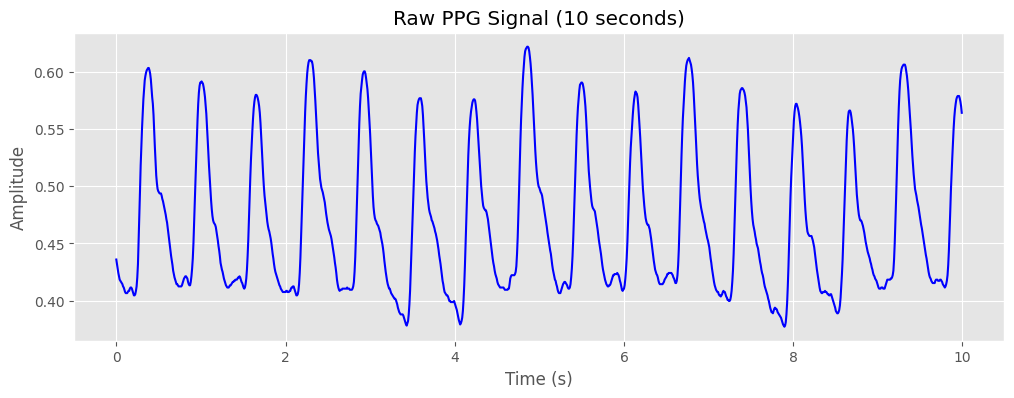

In [ ]:
fs = 125 # Sampling frequency is 125 Hz
base_dir = r"bidmc-ppg-and-respiration-dataset-1.0.0/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv"
sample_file = os.path.join(base_dir, "bidmc_01_Signals.csv")

# Load only the first 1250 samples (10 seconds)
df_sample = pd.read_csv(sample_file, nrows=1250)
df_sample.columns = [c.strip() for c in df_sample.columns]

time = df_sample['Time [s]'].values
raw_ppg = df_sample['PLETH'].values

plt.plot(time, raw_ppg, color='blue')
plt.title("Raw PPG Signal (10 seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

## 2. Fourier Transform
The FFT reveals the underlying frequency components, proving where the heart rate sits versus baseline noise.

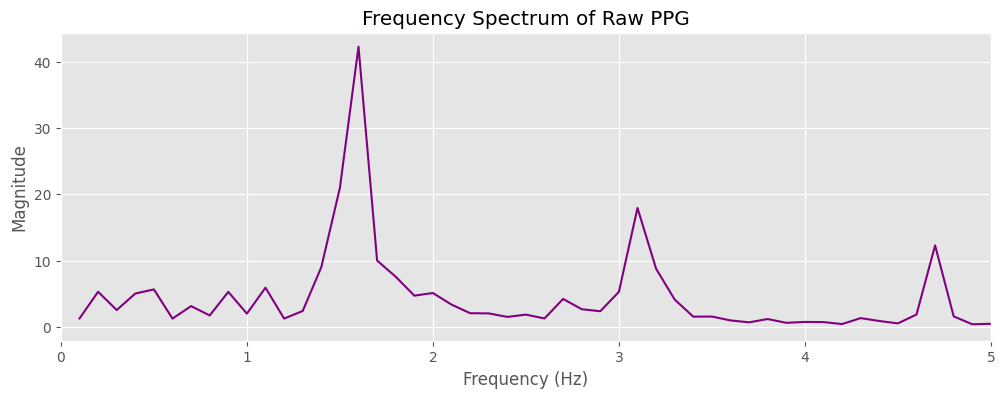

In [ ]:
fft_vals = np.fft.fft(raw_ppg)
fft_freqs = np.fft.fftfreq(len(raw_ppg), d=1/fs)

pos_mask = fft_freqs > 0
freqs = fft_freqs[pos_mask]
magnitudes = np.abs(fft_vals)[pos_mask]

plt.plot(freqs, magnitudes, color='purple')
plt.title("Frequency Spectrum of Raw PPG")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 5) 
plt.show()

## 3. Convolution-Based Filtering
Instead of applying a standard Butterworth math filter, we use **Convolution Masking** (Moving Average) to literally blur out the static noise to smooth the wave!

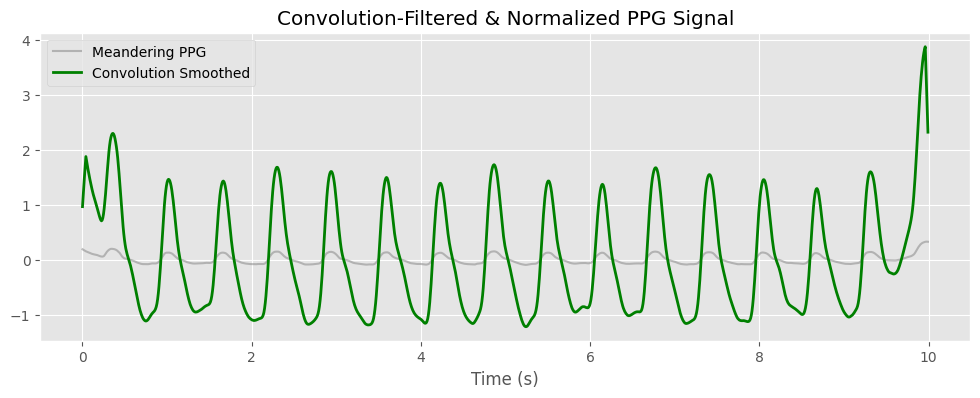

In [ ]:
def apply_convolution_filter(signal, window_size=15):
    # A simple moving average mask
    kernel = np.ones(window_size) / window_size
    return np.convolve(signal, kernel, mode='same')

# Center the signal and remove massive baseline drift easily with a large kernel
baseline = apply_convolution_filter(raw_ppg, window_size=fs) # 1 second blur
detrended_ppg = raw_ppg - baseline

# Apply standard Convolution smoothing
filtered_ppg = apply_convolution_filter(detrended_ppg, window_size=10)
filtered_ppg = (filtered_ppg - np.mean(filtered_ppg)) / np.std(filtered_ppg)

plt.plot(time, detrended_ppg, color='gray', alpha=0.5, label='Meandering PPG')
plt.plot(time, filtered_ppg, color='green', linewidth=2, label='Convolution Smoothed')
plt.title("Convolution-Filtered & Normalized PPG Signal")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

## 4. Normal Derivatives (Velocity & Acceleration)
We use regular `np.gradient` for the First Derivative and Second Derivative.

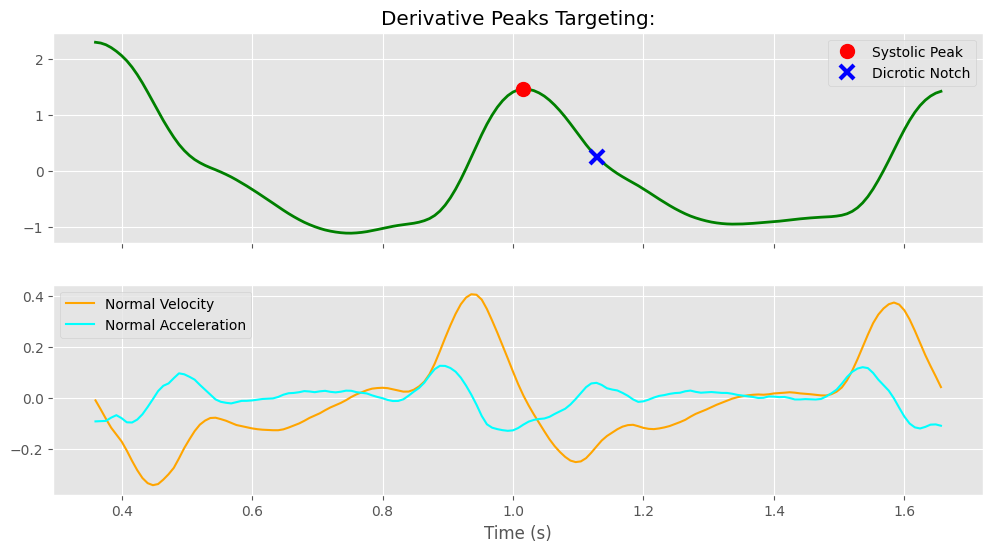

In [ ]:
# Calculating normal gradients
first_deriv = np.gradient(filtered_ppg)
second_deriv = np.gradient(first_deriv)

peaks, _ = find_peaks(filtered_ppg, distance=fs*0.5, prominence=0.5)

if len(peaks) > 2:
    p_idx = peaks[1]
    next_foot = p_idx + np.argmin(filtered_ppg[p_idx:peaks[2]])
    sec_deriv_segment = second_deriv[p_idx:next_foot]
    
    notch_idx = p_idx + np.argmax(sec_deriv_segment)
    
    start_idx = peaks[0]
    end_idx = peaks[2]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax1.plot(time[start_idx:end_idx], filtered_ppg[start_idx:end_idx], color='green', linewidth=2)
    ax1.plot(time[p_idx], filtered_ppg[p_idx], 'ro', markersize=10, label='Systolic Peak')
    ax1.plot(time[notch_idx], filtered_ppg[notch_idx], 'bx', markersize=10, markeredgewidth=3, label='Dicrotic Notch')
    ax1.legend()
    ax1.set_title("Derivative Peaks Targeting:")

    # Scaling down derivatives purely for visual overlay comparison
    ax2.plot(time[start_idx:end_idx], first_deriv[start_idx:end_idx]*2, color='orange', label='Normal Velocity')
    ax2.plot(time[start_idx:end_idx], second_deriv[start_idx:end_idx]*5, color='cyan', label='Normal Acceleration')
    ax2.legend()
    ax2.set_xlabel("Time (s)")
    plt.show()

## 5. Arterial Stiffness Index
The calculation maps exactly to the Convolution acceleration bump.

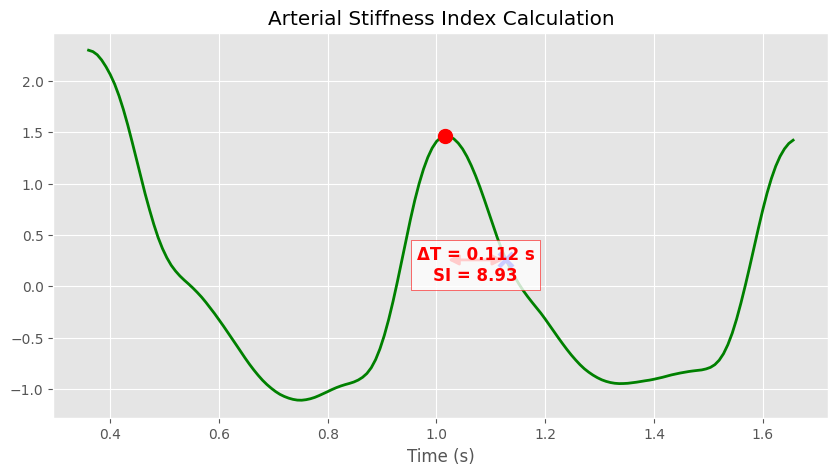

In [ ]:
from matplotlib.patches import FancyArrowPatch

delta_t_samples = notch_idx - p_idx
delta_t_sec = delta_t_samples / fs
stiffness_index = 1.0 / delta_t_sec if delta_t_sec > 0 else np.nan

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time[start_idx:end_idx], filtered_ppg[start_idx:end_idx], color='green', linewidth=2)
ax.plot(time[p_idx], filtered_ppg[p_idx], 'ro', markersize=10)
ax.plot(time[notch_idx], filtered_ppg[notch_idx], 'bx', markersize=10, markeredgewidth=3)

arrow = FancyArrowPatch((time[p_idx], filtered_ppg[notch_idx]), 
                        (time[notch_idx], filtered_ppg[notch_idx]), 
                        arrowstyle='<|-|>', color='red', mutation_scale=15, linewidth=2)
ax.add_patch(arrow)

ax.text((time[p_idx] + time[notch_idx])/2, filtered_ppg[notch_idx] - 0.2, 
        f'ΔT = {delta_t_sec:.3f} s\nSI = {stiffness_index:.2f}', 
        horizontalalignment='center', color='red', fontsize=12, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

ax.set_title("Arterial Stiffness Index Calculation")
ax.set_xlabel("Time (s)")
plt.show()

## 6. Compile Extracted Logic

In [ ]:
def extract_vascular_features(ppg_signal, fs=125):
    # Baseline Removal & Smoothing Convolution
    baseline = apply_convolution_filter(ppg_signal, window_size=fs)
    ppg_detrended = ppg_signal - baseline
    ppg_filtered = apply_convolution_filter(ppg_detrended, window_size=10)
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / (np.std(ppg_filtered) + 1e-8)

    # Normal Derivatives
    first_deriv = np.gradient(ppg_filtered)
    second_deriv = np.gradient(first_deriv)

    peaks, _ = find_peaks(ppg_filtered, distance=fs*0.5, prominence=0.5)

    sys_slopes = []
    dic_slopes = []
    delta_ts = []
    stiff_idxs = []

    for i in range(1, len(peaks)-1):
        p_idx = peaks[i]
        next_pk = peaks[i+1]
        prev_pk = peaks[i-1]

        foot = prev_pk + np.argmin(ppg_filtered[prev_pk:p_idx])
        next_foot = p_idx + np.argmin(ppg_filtered[p_idx:next_pk])

        if p_idx > foot:
            sys_slopes.append(np.max(first_deriv[foot:p_idx]))

        sec_seg = second_deriv[p_idx:next_foot]
        if len(sec_seg) > 5:
            notch_idx = p_idx + np.argmax(sec_seg)
            dt_samp = notch_idx - p_idx
            if dt_samp > 0:
                dt_sec = dt_samp / fs
                delta_ts.append(dt_sec)
                stiff_idxs.append(1.0 / dt_sec)
                if notch_idx < next_foot - 1:
                    dic_slopes.append(np.min(first_deriv[notch_idx:next_foot]))

    return {
        'Systolic_Slope': np.mean(sys_slopes) if sys_slopes else np.nan,
        'Dicrotic_Slope': np.mean(dic_slopes) if dic_slopes else np.nan,
        'Delta_T': np.mean(delta_ts) if delta_ts else np.nan,
        'Stiffness_Index': np.mean(stiff_idxs) if stiff_idxs else np.nan
    }

print("Executing feature extraction using normal gradients...")
features_list = []

for i in range(1, 54):
    subj_id = f"bidmc_{i:02d}"
    fix_path = os.path.join(base_dir, f"{subj_id}_Fix.txt")
    num_path = os.path.join(base_dir, f"{subj_id}_Numerics.csv")
    sig_path = os.path.join(base_dir, f"{subj_id}_Signals.csv")

    if not (os.path.exists(fix_path) and os.path.exists(sig_path)): continue

    age, gender = np.nan, ""
    with open(fix_path, 'r') as f:
        for line in f:
            if line.startswith("Age:"):
                a = line.split(":")[1].strip()
                age = 90 if a == '> 89' else int(a) if a.isdigit() else np.nan
            elif line.startswith("Gender:"):
                gender = line.split(":")[1].strip()

    try:
        num_df = pd.read_csv(num_path)
        hr, spo2 = num_df.iloc[:, 1].mean(), num_df.iloc[:, 4].mean()
    except:
        hr = spo2 = np.nan

    try:
        sig_df = pd.read_csv(sig_path)
        feats = extract_vascular_features(sig_df.iloc[:, 2].values, fs=125)
    except:
        feats = {'Systolic_Slope': np.nan, 'Dicrotic_Slope': np.nan, 'Delta_T': np.nan, 'Stiffness_Index': np.nan}

    features_list.append({'Subject': subj_id, 'Age': age, 'Gender': gender, 'Mean_HR': hr, 'Mean_SpO2': spo2, **feats})

df_final = pd.DataFrame(features_list)
df_final.to_csv("compiled_vascular_features.csv", index=False)



Executing feature extraction using normal gradients...


## 7. Statistical Correlation: Age vs Stiffness Index
We correlate the extracted Stiffness Index with Age and visualize the relationship using a scatter plot and regression line.

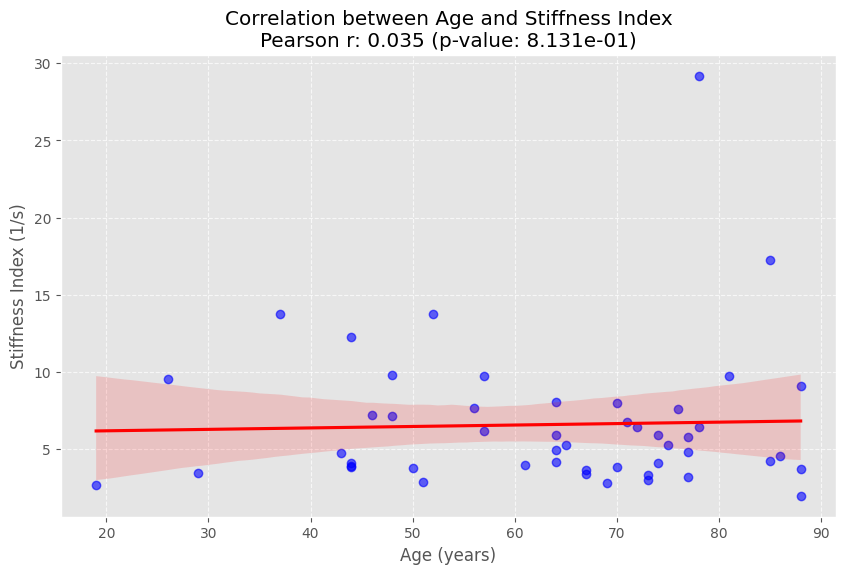

In [ ]:
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Drop NaN values for accurate correlation calculation
df_clean = df_final.dropna(subset=['Age', 'Stiffness_Index']).copy()

# Ensure numeric types
df_clean['Age'] = df_clean['Age'].astype(float)
df_clean['Stiffness_Index'] = df_clean['Stiffness_Index'].astype(float)

plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='Age', y='Stiffness_Index', scatter_kws={'alpha':0.6, 'color':'b'}, line_kws={'color':'r'})

if len(df_clean) > 1:
    corr, pval = pearsonr(df_clean['Age'], df_clean['Stiffness_Index'])
    plt.title(f"Correlation between Age and Stiffness Index\nr: {corr:.3f} (p-value: {pval:.3e})")
else:
    plt.title("Correlation between Age and Stiffness Index\nNot enough valid data points for correlation.")

plt.xlabel("Age (years)")
plt.ylabel("Stiffness Index (1/s)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## 8. Final Compiled Data
The final extracted vascular features across the entire dataset are displayed below.

In [ ]:
display(df_final.head(10))

,Subject,Age,Gender,Mean_HR,Mean_SpO2,Systolic_Slope,Dicrotic_Slope,Delta_T,Stiffness_Index
0,bidmc_01,88.0,M,91.318087,96.916667,0.236996,-0.097927,0.115753,9.086024
1,bidmc_02,65.0,M,91.066528,99.989605,0.191401,-0.078153,0.241201,5.243784
2,bidmc_03,46.0,F,76.638254,95.750520,0.233377,-0.062285,0.173435,7.170213
3,bidmc_04,78.0,M,92.397089,93.000000,0.209945,-0.088713,0.169575,6.445930
4,bidmc_05,73.0,F,98.209979,99.378947,0.176454,-0.064350,0.367612,2.985906
5,bidmc_06,64.0,F,81.841996,99.000000,0.364207,-0.081733,0.172224,8.014842
6,bidmc_07,64.0,F,90.097713,94.997921,0.239390,-0.077685,0.173578,5.912058
7,bidmc_08,64.0,F,99.948025,93.000000,0.236652,-0.082452,0.242512,4.947027
8,bidmc_09,64.0,F,76.740125,93.000000,0.235561,-0.073873,0.242474,4.143427
9,bidmc_10,74.0,M,82.145530,97.950104,0.187711,-0.075193,0.197156,5.920293


## 10. Estimating Vascular Age
Here we build a regression model to estimate vascular age based on the extracted PPG features. We will correlate the estimated age with the real chronological age and visualize the results.

In [ ]:
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Load the compiled features
df_features = pd.read_csv('compiled_vascular_features.csv')

# 2. Clean the data (Drop missing 'Age' rows)
df_features = df_features.dropna(subset=['Age'])
df_features['Age'] = df_features['Age'].astype(float)

# Fill any missing feature values with median
numeric_cols = ['Mean_HR', 'Mean_SpO2', 'Systolic_Slope', 'Dicrotic_Slope', 'Delta_T', 'Stiffness_Index']
df_features[numeric_cols] = df_features[numeric_cols].apply(lambda x: x.fillna(x.median()))

# 3. Define features and target (Real Age)
X = df_features[numeric_cols]
y = df_features['Age']

# 4. Build a model to estimate Vascular Age
# Using a simple Linear Regression model for explainability
model = LinearRegression()
model.fit(X, y)

# Estimate the vascular age based on the model
df_features['Estimated_Vascular_Age'] = model.predict(X)

# 5. Correlate estimated vascular age to real age
correlation, p_value = pearsonr(df_features['Age'], df_features['Estimated_Vascular_Age'])
mae = mean_absolute_error(df_features['Age'], df_features['Estimated_Vascular_Age'])

print(f"Pearson Correlation (r): {correlation:.3f} (p-value: {p_value:.3e})")
print(f"Mean Absolute Error (MAE): {mae:.2f} years")

# 6. Visualize the correlation
plt.figure(figsize=(8, 6))
sns.regplot(
    x='Age', 
    y='Estimated_Vascular_Age', 
    data=df_features, 
    scatter_kws={'alpha': 0.7, 's': 50}, 
    line_kws={'color': 'red', 'linestyle': '--'}
)

plt.title(f'Real Age vs Estimated Vascular Age\nCorrelation: {correlation:.3f}')
plt.xlabel('Real Age (Chronological) [Years]')
plt.ylabel('Estimated Vascular Age [Years]')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 10. Estimating Vascular Age
Here we build a regression model to estimate vascular age based on the extracted PPG features. We will correlate the estimated age with the real chronological age and visualize the results.

In [ ]:
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Load the compiled features
df_features = pd.read_csv('compiled_vascular_features.csv')

# 2. Clean the data (Drop missing 'Age' rows)
df_features = df_features.dropna(subset=['Age'])
df_features['Age'] = df_features['Age'].astype(float)

# Fill any missing feature values with median
numeric_cols = ['Mean_HR', 'Mean_SpO2', 'Systolic_Slope', 'Dicrotic_Slope', 'Delta_T', 'Stiffness_Index']
df_features[numeric_cols] = df_features[numeric_cols].apply(lambda x: x.fillna(x.median()))

# 3. Define features and target (Real Age)
X = df_features[numeric_cols]
y = df_features['Age']

# 4. Build a model to estimate Vascular Age
# Using a simple Linear Regression model for explainability
model = LinearRegression()
model.fit(X, y)

# Estimate the vascular age based on the model
df_features['Estimated_Vascular_Age'] = model.predict(X)

# 5. Correlate estimated vascular age to real age
correlation, p_value = pearsonr(df_features['Age'], df_features['Estimated_Vascular_Age'])
mae = mean_absolute_error(df_features['Age'], df_features['Estimated_Vascular_Age'])

print(f"Pearson Correlation (r): {correlation:.3f} (p-value: {p_value:.3e})")
print(f"Mean Absolute Error (MAE): {mae:.2f} years")

# 6. Visualize the correlation
plt.figure(figsize=(8, 6))
sns.regplot(
    x='Age', 
    y='Estimated_Vascular_Age', 
    data=df_features, 
    scatter_kws={'alpha': 0.7, 's': 50}, 
    line_kws={'color': 'red', 'linestyle': '--'}
)

plt.title(f'Real Age vs Estimated Vascular Age\nCorrelation: {correlation:.3f}')
plt.xlabel('Real Age (Chronological) [Years]')
plt.ylabel('Estimated Vascular Age [Years]')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()